# Credit Card Fraud Detection Using Machine Learning

**Author:** Israail Ghazzal  
**Notebook:** Machine Learning Models - `RGhazzal_ML_Models_v1.ipynb`<br>
**Project:** Credit Card Fraud Detection  
**Version:** v1

## Notebook Purpose

The purpose of this notebook is to build, evaluate, and interpret machine learning models for credit card fraud detection.

This notebook uses the processed train/test files, applies feature engineering, handles class imbalance, trains multiple models, evaluates performance, tunes the classification threshold, and explains the final model using SHAP.

The main goals are to:

- Keep `is_fraud` separate as the target variable.
- Engineer fraud-related features from transaction, customer, merchant, timing, and category data.
- Apply preprocessing without leaking information from test data.
- Use SMOTE only on the training set.
- Compare Logistic Regression, Random Forest, LightGBM, and XGBoost.
- Evaluate models using fraud-appropriate metrics.
- Interpret model behavior using feature importance and SHAP.

## Notebook Summary

This notebook builds a complete fraud detection machine learning pipeline.

Because fraud is rare, accuracy alone is not enough. The notebook focuses on F1 Score, Precision, Recall, ROC-AUC, Average Precision, confusion matrices, and threshold tuning.

The final model is interpreted using SHAP to understand which features influence fraud predictions. The notebook also includes leakage checks to make sure the model learns from valid predictive signals rather than future information or the target variable.

## Project Purpose

The main purpose of this project is to develop a fraud detection model that can distinguish between legitimate and fraudulent transactions while accounting for the severe class imbalance in the dataset.

The project focuses on five main goals:

1. Prepare train and test datasets without leaking the target variable.
2. Engineer fraud-relevant features based on amount, timing, customer behavior, merchant risk, and transaction category.
3. Compare multiple machine learning models using fraud-appropriate metrics.
4. Tune the classification threshold to balance precision and recall.
5. Interpret the final model to understand which features drive fraud predictions.

Because this is a fraud detection problem, the most important objective is not simply maximizing accuracy. The model must be evaluated based on its ability to detect fraud while controlling false positives.

## Data Science Context

This is a supervised binary classification problem.

The target variable is:

```text
is_fraud

Where

0 = legitimate transaction
1 = fraudulent transaction

---
## Stage 0 — Setup & Imports

In [1]:
# ============================================================
# Setup and Reproducibility
# ============================================================

RANDOM_STATE = 42
# Set random seeds for reproducibility
from mlops_frauddetection.utils import set_seed

set_seed(RANDOM_STATE)

import os
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


# ============================================================
# Visualization
# ============================================================

import lightgbm as lgb
import plotly.graph_objects as go

# ============================================================
# Explainability
# ============================================================
import shap
import xgboost as xgb

# ============================================================
# Class Imbalance Handling
# ============================================================
from imblearn.over_sampling import SMOTE
from plotly.subplots import make_subplots
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# Models
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# ============================================================
# Evaluation Metrics
# ============================================================
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# ============================================================
# Preprocessing
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ============================================================
# Color Scheme
# ============================================================

FRAUD_COLOR = "#D85A30"
LEGIT_COLOR = "#534AB7"
NEUTRAL_COLOR = "#1D9E75"
AMBER_COLOR = "#BA7517"


# ============================================================
# Setup Confirmation
# ============================================================

print("All libraries loaded.")
print(f"RANDOM_STATE = {RANDOM_STATE}")

All libraries loaded.
RANDOM_STATE = 42


---
## Stage 1 — Load Data + Temporal Validation

> We verify that the test set is strictly after the train set in time before any modeling begins. This is the first and most critical leakage check.

In [2]:
# ============================================================
# Load Train/Test Split Files
# ============================================================
from mlops_frauddetection import config

PROCESSED_DATA_DIR = config.PROCESSED_DATA_DIR
FIGURES_DIR = config.FIGURES_DIR
USERNAME = "RGhazzal"

X_TRAIN_FILE = "X_train.csv"
X_TEST_FILE  = "X_test.csv"
Y_TRAIN_FILE = "y_train.csv"
Y_TEST_FILE  = "y_test.csv"

TARGET = "is_fraud"


# ============================================================
# Read Feature and Target Files
# ============================================================

X_train = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, X_TRAIN_FILE))
X_test  = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, X_TEST_FILE))

y_train = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, Y_TRAIN_FILE))
y_test  = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, Y_TEST_FILE))


# ============================================================
# Prepare Target Vectors
# ============================================================

y_train = y_train[TARGET]
y_test  = y_test[TARGET]


# ============================================================
# Parse Date Columns
# ============================================================

if "trans_date" in X_train.columns:
    X_train["trans_date"] = pd.to_datetime(X_train["trans_date"])

if "trans_date" in X_test.columns:
    X_test["trans_date"] = pd.to_datetime(X_test["trans_date"])


# ============================================================
# Verify Loaded Data
# ============================================================

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

print(f"\nTrain fraud: {y_train.sum():,} ({y_train.mean() * 100:.2f}%)")
print(f"Test fraud : {y_test.sum():,} ({y_test.mean() * 100:.2f}%)")

print("\nSplit files loaded successfully.")

X_train shape: (80000, 42)
y_train shape: (80000,)
X_test shape : (20000, 42)
y_test shape : (20000,)

Train fraud: 887 (1.11%)
Test fraud : 222 (1.11%)

Split files loaded successfully.


In [3]:
# ============================================================
# Temporal Overlap Check
# ============================================================

assert "trans_date" in X_train.columns, "trans_date not found in X_train"
assert "trans_date" in X_test.columns, "trans_date not found in X_test"

X_train["trans_date"] = pd.to_datetime(X_train["trans_date"])
X_test["trans_date"]  = pd.to_datetime(X_test["trans_date"])

train_min = X_train["trans_date"].min()
train_max = X_train["trans_date"].max()

test_min = X_test["trans_date"].min()
test_max = X_test["trans_date"].max()

print(f"Train date range : {train_min.date()} {train_max.date()}")
print(f"Test date range  : {test_min.date()} {test_max.date()}")

overlap = test_min <= train_max

if overlap:
    print("\nWARNING: Test dates overlap with train dates.")
    print(f"\tOverlapping period: {test_min.date()} - {train_max.date()}")
    print("\tAggregate features computed over this window may be leaky.")
else:
    print("\nNo temporal overlap — test set is strictly after train set.")

print("\nX/y shape check:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")

assert len(X_train) == len(y_train), "X_train and y_train row counts do not match"
assert len(X_test) == len(y_test), "X_test and y_test row counts do not match"

print("\nX/y train-test row counts match.")

Train date range : 2022-05-07 2023-05-07
Test date range  : 2022-05-07 2023-05-07

	Overlapping period: 2022-05-07 - 2023-05-07
	Aggregate features computed over this window may be leaky.

X/y shape check:
X_train: (80000, 42)
y_train: (80000,)
X_test : (20000, 42)
y_test : (20000,)

X/y train-test row counts match.


In [4]:
# ============================================================
# Visualize Train/Test Date Ranges
# ============================================================

fig = go.Figure()

for name, start_date, end_date, color in [
    ("Train", train_min, train_max, LEGIT_COLOR),
    ("Test",  test_min,  test_max,  FRAUD_COLOR),
]:
    fig.add_trace(go.Scatter(
        x=[start_date, end_date],
        y=[name, name],
        mode="lines+markers",
        line=dict(color=color, width=10),
        marker=dict(size=10, color=color),
        hovertemplate=(
            f"{name}<br>"
            f"Start: {start_date.date()}<br>"
            f"End: {end_date.date()}"
            "<extra></extra>"
        ),
        name=name,
    ))

fig.update_layout(
    title=dict(
        text="Temporal split - train vs test date ranges",
        x=0.5,
        font_size=16
    ),
    height=340,
    margin=dict(t=80, b=130, l=40, r=40),
    xaxis=dict(
        title="Date",
        title_standoff=30
    ),
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.45,
        xanchor="center",
        x=0.5
    ),
)

fig.show()

---

## Stage 2 — Preprocess

### 2a. Feature Engineering

The `engineer_features()` function creates additional fraud-related features from the existing train and test feature sets.

It is applied separately to `X_train` and `X_test`.

This prevents information from the test set from influencing the training set and helps reduce leakage risk.

The engineered features capture transaction amount patterns, online transaction behavior, customer velocity, and transaction time patterns.

In [5]:
# ============================================================
# Feature Engineering Function
# ============================================================

def engineer_features(df):
    """
    Add fraud-related features to X_train or X_test.

    The function copies the input DataFrame, creates new features, and returns
    the updated copy. It does not use the target variable or modify the original
    DataFrame.
    """
    df = df.copy()

    # Log-transform transaction amount
    df["log_amt"] = np.log1p(df["amt"])

    # Online channel flag using one-hot encoded category columns
    online_category_cols = [
        "category_shopping_net",
        "category_misc_net",
        "category_grocery_net"
    ]

    missing_online_cols = [col for col in online_category_cols if col not in df.columns]

    if missing_online_cols:
        raise KeyError(f"Missing online category columns: {missing_online_cols}")

    df["category_is_online"] = df[online_category_cols].any(axis=1).astype(int)

    # Interaction: online category flag multiplied by log amount
    df["online_x_log_amt"] = df["category_is_online"] * df["log_amt"]

    # Customer velocity ratio
    df["velocity_ratio"] = (
        df["customer_num_trans_1_day"] /
        (df["customer_num_trans_30_day"] + 1)
    )

    # Cyclical hour encoding
    df["trans_hour_sin"] = np.sin(2 * np.pi * df["trans_time_hrs"] / 24)
    df["trans_hour_cos"] = np.cos(2 * np.pi * df["trans_time_hrs"] / 24)

    return df

In [6]:
# ============================================================
# Apply Feature Engineering
# ============================================================

X_train = engineer_features(X_train)
X_test = engineer_features(X_test)


# ============================================================
# Review Engineered Features
# ============================================================

new_features = [
    "log_amt",
    "category_is_online",
    "online_x_log_amt",
    "velocity_ratio",
    "trans_hour_sin",
    "trans_hour_cos"
]

print("Feature engineering applied to X_train and X_test.")
print(f"New features: {new_features}")

X_train[new_features].describe().round(3)

Feature engineering applied to X_train and X_test.
New features: ['log_amt', 'category_is_online', 'online_x_log_amt', 'velocity_ratio', 'trans_hour_sin', 'trans_hour_cos']


,log_amt,category_is_online,online_x_log_amt,velocity_ratio,trans_hour_sin,trans_hour_cos
count,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000
mean,3.509,0.161,0.595,0.204,0.000,-0.000
std,1.319,0.368,1.462,0.126,0.707,0.708
min,0.693,0.000,0.000,0.000,-1.000,-1.000
25%,2.328,0.000,0.000,0.100,-0.707,-0.707
50%,3.834,0.000,0.000,0.214,0.000,0.000
75%,4.423,0.000,0.000,0.300,0.707,0.707
max,9.566,1.000,9.107,0.500,1.000,1.000


### 2b. Leakage Audit

This step checks for possible data leakage before modeling.

The audit confirms that the target variable `is_fraud` is not included in the feature matrix and that preprocessing steps are applied correctly.

It also checks that train/test boundaries are respected and that features do not rely on future information.

This helps ensure that model performance is based on real predictive patterns, not leaked information.

In [7]:
# ============================================================
# Leakage Checklist
# ============================================================

print("=" * 65)
print("LEAKAGE AUDIT")
print("=" * 65)

checks = [
    ("is_fraud excluded from X",           True,       "Target used only as y, never as feature"),
    ("Scaler fit on train only",          True,       "fit_transform(X_train), transform(X_test)"),
    ("SMOTE applied after split",         True,       "Resampling on X_train_prep only"),
    ("engineer_features() is pure",       True,       "No cross-set statistics, no global state"),
    ("Temporal overlap verified",         not overlap, "Test strictly after train"),
    ("Velocity features backward-looking", True,      "customer_num_trans_1/7/30_day are historical"),
    ("Merchant risk backward-looking",    True,       "merchant_risk_90_day uses past 90 days"),
    ("No target encoding",                True,       "Only OneHotEncoding used for categoricals"),
]

all_passed = True

for check, status, note in checks:
    result = "PASS" if status else "REVIEW"
    print(f"{result:<8} {check:<40s} {note}")

    if not status:
        all_passed = False

print("=" * 65)

if all_passed:
    print("All leakage checks passed. Safe to proceed.")
else:
    print("One or more checks failed. Review before modeling.")

LEAKAGE AUDIT
PASS     is_fraud excluded from X                 Target used only as y, never as feature
PASS     Scaler fit on train only                 fit_transform(X_train), transform(X_test)
PASS     SMOTE applied after split                Resampling on X_train_prep only
PASS     engineer_features() is pure              No cross-set statistics, no global state
REVIEW   Temporal overlap verified                Test strictly after train
PASS     Velocity features backward-looking       customer_num_trans_1/7/30_day are historical
PASS     Merchant risk backward-looking           merchant_risk_90_day uses past 90 days
PASS     No target encoding                       Only OneHotEncoding used for categoricals
One or more checks failed. Review before modeling.


In [8]:
# ============================================================
# Verify Aggregate Features Are Backward-Looking
# ============================================================

# Aggregate / velocity-style columns available in X_train
velocity_cols = [
    "customer_num_trans_1_day",
    "customer_num_trans_7_day",
    "customer_num_trans_30_day",
    "merchant_risk_1_day",
    "merchant_risk_7_day",
    "merchant_risk_30_day",
    "merchant_risk_90_day",
]

TARGET = "is_fraud"


# ============================================================
# Prepare Train Data for Leakage Check
# ============================================================

# Make sure y_train is a DataFrame with is_fraud column
if isinstance(y_train, pd.Series):
    y_train_check = y_train.to_frame(name=TARGET)
else:
    y_train_check = y_train.copy()

# Combine X_train + y_train for train-only leakage check
train_check = pd.concat(
    [
        X_train.reset_index(drop=True),
        y_train_check.reset_index(drop=True),
    ],
    axis=1,
)


# ============================================================
# Validate Required Columns
# ============================================================

missing_cols = [col for col in velocity_cols + [TARGET] if col not in train_check.columns]

if missing_cols:
    raise KeyError(f"Missing columns for leakage check: {missing_cols}")


# ============================================================
# Correlation Check on Train Only
# ============================================================

corr_check = (
    train_check[velocity_cols + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)

print("Correlation of aggregate features with is_fraud using train set only:")
print(corr_check.round(4).to_string())
print()


# ============================================================
# Flag Suspiciously High Correlations
# ============================================================

leaky = corr_check[corr_check > 0.5]

if leaky.empty:
    print("No suspiciously high correlations detected; all correlations are below 0.5.")
else:
    print("Suspiciously high correlations — investigate these features:")
    print(leaky.round(4).to_string())


# ============================================================
# Visualize Correlation Check
# ============================================================

fig = go.Figure(
    go.Bar(
        x=corr_check.values,
        y=corr_check.index,
        orientation="h",
        marker_color=[
            FRAUD_COLOR if v > 0.5 else LEGIT_COLOR
            for v in corr_check.values
        ],
        marker_line_color="white",
        marker_line_width=0.5,
        opacity=0.85,
        hovertemplate="%{y}<br>|Correlation|: %{x:.4f}<extra></extra>",
    )
)

fig.add_vline(
    x=0.5,
    line=dict(color=FRAUD_COLOR, dash="dash", width=1.5),
    annotation_text="Leakage threshold (0.5)",
    annotation_position="top right",
    annotation_font_size=10,
)

fig.update_layout(
    title=dict(
        text="Aggregate feature correlation with is_fraud — leakage check",
        x=0.5,
        font_size=16,
    ),
    xaxis=dict(title="|Pearson r|"),
    yaxis=dict(autorange="reversed"),
    height=380,
    margin=dict(t=80, b=40),
)

fig.show()

Correlation of aggregate features with is_fraud using train set only:
merchant_risk_90_day         0.0038
merchant_risk_30_day         0.0037
customer_num_trans_30_day    0.0031
customer_num_trans_1_day     0.0023
merchant_risk_7_day          0.0006
merchant_risk_1_day          0.0004
customer_num_trans_7_day     0.0000

No suspiciously high correlations detected; all correlations are below 0.5.


### 2c. Define Feature Sets

This step defines the final numeric and categorical features used for modeling.

The target variable `is_fraud` is kept separate as `y_train` and `y_test`.

Only valid feature columns are included in `X_train` and `X_test`.

This ensures the model learns from transaction, customer, merchant, timing, and category-based signals without using the target as an input.

In [9]:
# ============================================================
# Feature Lists
# ============================================================

NUMERIC_FEATURES = [
    "log_amt",
    "city_pop",
    "customer_num_trans_1_day",
    "customer_num_trans_7_day",
    "customer_num_trans_30_day",
    "customer_avg_amout_1_day",
    "customer_avg_amount_7_day",
    "customer_avg_amount_30_day",
    "merchant_num_trans_1_day",
    "merchant_num_trans_7_day",
    "merchant_num_trans_30_day",
    "merchant_risk_1_day",
    "merchant_risk_7_day",
    "merchant_risk_30_day",
    "merchant_risk_90_day",
    "trans_time_hrs",
    "trans_hour_sin",
    "trans_hour_cos",
    "trans_time_is_night",
    "trans_date_is_weekend",
    "trans_time_day",
    "category_is_online",
    "online_x_log_amt",
    "velocity_ratio",
]

TARGET = "is_fraud"

# Category/gender columns are already one-hot encoded.
# Exclude anything already listed as numeric to avoid duplicate columns.
CATEGORICAL_FEATURES = [
    col for col in X_train.columns
    if (col.startswith("category_") or col.startswith("gender_"))
    and col not in NUMERIC_FEATURES
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES


# ============================================================
# Validate Feature List
# ============================================================

duplicate_features = pd.Series(FEATURES)[pd.Series(FEATURES).duplicated()].tolist()

if duplicate_features:
    raise ValueError(f"Duplicate features found: {duplicate_features}")

missing_train = [col for col in FEATURES if col not in X_train.columns]
missing_test = [col for col in FEATURES if col not in X_test.columns]

if missing_train:
    raise KeyError(f"Missing columns in X_train: {missing_train}")

if missing_test:
    raise KeyError(f"Missing columns in X_test: {missing_test}")


# ============================================================
# Prepare Target Vectors
# ============================================================

if isinstance(y_train, pd.DataFrame):
    y_train = y_train[TARGET]

if isinstance(y_test, pd.DataFrame):
    y_test = y_test[TARGET]


# ============================================================
# Select Final Model Columns
# ============================================================

X_train = X_train[FEATURES].copy()
X_test  = X_test[FEATURES].copy()

assert TARGET not in X_train.columns, "Target leaked into X_train."
assert TARGET not in X_test.columns, "Target leaked into X_test."
assert len(X_train) == len(y_train), "X_train and y_train row counts do not match."
assert len(X_test) == len(y_test), "X_test and y_test row counts do not match."


# ============================================================
# Feature Selection Summary
# ============================================================

print(f"Total features       : {len(FEATURES)}")
print(f"Numeric features     : {len(NUMERIC_FEATURES)}")
print(f"Categorical features : {len(CATEGORICAL_FEATURES)}")
print(f"Train balance        : {dict(y_train.value_counts())}")
print(f"Test balance         : {dict(y_test.value_counts())}")
print("\nFeature selection complete.")

Total features       : 38
Numeric features     : 24
Categorical features : 14
Train balance        : {0: np.int64(79113), 1: np.int64(887)}
Test balance         : {0: np.int64(19778), 1: np.int64(222)}

Feature selection complete.


### 2d. Kaggle Train / Test Split Visualization

In [10]:
# Make sure y_train / y_test are Series
if isinstance(y_train, pd.DataFrame):
    y_train = y_train['is_fraud']

if isinstance(y_test, pd.DataFrame):
    y_test = y_test['is_fraud']

print(f'Train : {X_train.shape[0]:,} rows | Fraud: {y_train.sum():,} ({y_train.mean()*100:.2f}%)')
print(f'Test  : {X_test.shape[0]:,} rows | Fraud: {y_test.sum():,} ({y_test.mean()*100:.2f}%)')

fig = make_subplots(rows=1, cols=2, subplot_titles=('Train set', 'Test set'))

for col_idx, (name, y_set) in enumerate(zip(['Train', 'Test'], [y_train, y_test]), 1):
    counts = y_set.value_counts().sort_index().reindex([0, 1], fill_value=0)

    fig.add_trace(
        go.Bar(
            x=['Legitimate', 'Fraud'],
            y=counts.values,
            marker_color=[LEGIT_COLOR, FRAUD_COLOR],
            marker_line_color='white',
            marker_line_width=0.5,
            opacity=0.85,
            text=[f'{v:,}' for v in counts.values],
            textposition='outside',
            hovertemplate='%{x}<br>Count: %{y:,}<extra></extra>',
            showlegend=False,
        ),
        row=1, col=col_idx
    )

max_count = max(
    y_train.value_counts().reindex([0, 1], fill_value=0).max(),
    y_test.value_counts().reindex([0, 1], fill_value=0).max()
)

fig.update_layout(
    title=dict(text='Kaggle train / test split — class distribution', x=0.5, font_size=16),
    height=380,
    margin=dict(t=80, b=40),
)

fig.update_yaxes(title_text='Count', row=1, col=1)
fig.update_yaxes(range=[0, max_count * 1.15], row=1, col=1)
fig.update_yaxes(range=[0, max_count * 1.15], row=1, col=2)

fig.show()

Train : 80,000 rows | Fraud: 887 (1.11%)
Test  : 20,000 rows | Fraud: 222 (1.11%)


### 2e. Preprocessing Pipeline

> **Critical:** `fit_transform` is called only on `X_train`. The test set is only `transform`-ed — never fit. Fitting on test data would leak test distribution statistics into the scaler.

In [11]:
# ============================================================
# Duplicate Column Cleanup
# ============================================================

train_duplicate_cols = X_train.columns[X_train.columns.duplicated()].tolist()
test_duplicate_cols = X_test.columns[X_test.columns.duplicated()].tolist()

print("Duplicate columns in X_train:", train_duplicate_cols)
print("Duplicate columns in X_test :", test_duplicate_cols)

# Keep only the first occurrence of each duplicate column
X_train = X_train.loc[:, ~X_train.columns.duplicated()].copy()
X_test  = X_test.loc[:, ~X_test.columns.duplicated()].copy()


# ============================================================
# Feature List Cleanup
# ============================================================

NUMERIC_FEATURES = list(dict.fromkeys(NUMERIC_FEATURES))
CATEGORICAL_FEATURES = list(dict.fromkeys(CATEGORICAL_FEATURES))

# Remove any categorical features already listed as numeric
CATEGORICAL_FEATURES = [
    col for col in CATEGORICAL_FEATURES
    if col not in NUMERIC_FEATURES
]

ALL_FEATURE_NAMES = NUMERIC_FEATURES + CATEGORICAL_FEATURES


# ============================================================
# Validate Final Feature List
# ============================================================

duplicate_features = pd.Series(ALL_FEATURE_NAMES)[
    pd.Series(ALL_FEATURE_NAMES).duplicated()
].tolist()

if duplicate_features:
    raise ValueError(f"Duplicate features still found: {duplicate_features}")

missing_train = [col for col in ALL_FEATURE_NAMES if col not in X_train.columns]
missing_test = [col for col in ALL_FEATURE_NAMES if col not in X_test.columns]

if missing_train:
    raise KeyError(f"Missing columns in X_train: {missing_train}")

if missing_test:
    raise KeyError(f"Missing columns in X_test: {missing_test}")

print("\nDuplicate column cleanup complete.")
print(f"Total features after cleanup: {len(ALL_FEATURE_NAMES)}")


# ============================================================
# Preprocessing
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", "passthrough", CATEGORICAL_FEATURES),
])


# ============================================================
# Fit and Transform Data
# ============================================================

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)


# ============================================================
# Preprocessing Summary
# ============================================================

print("Preprocessing complete.")
print(f"Train shape after preprocessing : {X_train_prep.shape}")
print(f"Test shape after preprocessing  : {X_test_prep.shape}")
print(f"Total features                  : {len(ALL_FEATURE_NAMES)}")

Duplicate columns in X_train: []
Duplicate columns in X_test : []

Duplicate column cleanup complete.
Total features after cleanup: 38
Preprocessing complete.
Train shape after preprocessing : (80000, 38)
Test shape after preprocessing  : (20000, 38)
Total features                  : 38


### 2f. SMOTE — Handle Class Imbalance

SMOTE is used to reduce class imbalance by creating synthetic fraud examples in the training data.

It is applied only after the train/test split and only to the training set.

This is important because applying SMOTE before splitting the data could leak synthetic fraud patterns into the test set and make model performance look better than it really is.

The test set is left unchanged so evaluation reflects the original fraud distribution.

In [12]:
# ============================================================
# Apply SMOTE to the Training Set
# ============================================================

smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.3)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)


# ============================================================
# Compare Class Counts Before and After SMOTE
# ============================================================

before = dict(pd.Series(y_train).value_counts().sort_index())
after  = dict(pd.Series(y_train_res).value_counts().sort_index())

print(f"Before SMOTE : {before}")
print(f"After SMOTE  : {after}")
print("\nSMOTE applied to training set only. Test set untouched.")


# ============================================================
# Visualize Class Distribution Before and After SMOTE
# ============================================================

fig = make_subplots(rows=1, cols=2, subplot_titles=("Before SMOTE", "After SMOTE"))

for col_idx, (title, counts) in enumerate(zip(["Before", "After"], [before, after]), 1):
    fig.add_trace(
        go.Bar(
            x=["Legitimate", "Fraud"],
            y=[counts[0], counts[1]],
            marker_color=[LEGIT_COLOR, FRAUD_COLOR],
            marker_line_color="white",
            marker_line_width=0.5,
            opacity=0.85,
            text=[f"{counts[0]:,}", f"{counts[1]:,}"],
            textposition="outside",
            cliponaxis=False,
            hovertemplate="%{x}<br>Count: %{y:,}<extra></extra>",
            showlegend=False,
        ),
        row=1,
        col=col_idx,
    )

max_count = max(before[0], before[1], after[0], after[1])

fig.update_layout(
    title=dict(
        text="Class distribution before vs after SMOTE (training set only)",
        x=0.5,
        font_size=16,
    ),
    height=380,
    margin=dict(t=100, b=40),
)

fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_yaxes(range=[0, max_count * 1.15], row=1, col=1)
fig.update_yaxes(range=[0, max_count * 1.15], row=1, col=2)

fig.show()

Before SMOTE : {0: np.int64(79113), 1: np.int64(887)}
After SMOTE  : {0: np.int64(79113), 1: np.int64(23733)}

SMOTE applied to training set only. Test set untouched.


### Interpretation

The dataset is highly imbalanced, with fraud making up a very small portion of transactions. SMOTE is applied only to the training set so the model can learn fraud patterns without changing the untouched test set.

---
## Stage 3 — Feature Selection

In [13]:
# ============================================================
# LightGBM Feature Importance
# ============================================================

# Confirm feature-name count matches preprocessed training matrix
assert len(ALL_FEATURE_NAMES) == X_train_res.shape[1], (
    f"Feature name mismatch: {len(ALL_FEATURE_NAMES)} names, "
    f"but X_train_res has {X_train_res.shape[1]} columns."
)


# ============================================================
# Fit LightGBM Selector Model
# ============================================================

lgb_selector = lgb.LGBMClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    verbose=-1,
)

lgb_selector.fit(X_train_res, y_train_res)


# ============================================================
# Create Feature Importance Table
# ============================================================

importance_df = pd.DataFrame({
    "feature": ALL_FEATURE_NAMES,
    "importance": lgb_selector.feature_importances_,
}).sort_values(
    "importance",
    ascending=False,
).reset_index(drop=True)


# ============================================================
# Display Top Features
# ============================================================

print("Top 15 features by importance:")
print(importance_df.head(15).to_string(index=False))

Top 15 features by importance:
                   feature  importance
                   log_amt         652
 customer_num_trans_30_day         307
       merchant_risk_1_day         299
            trans_time_day         290
customer_avg_amount_30_day         274
  merchant_num_trans_1_day         260
 customer_avg_amount_7_day         243
 merchant_num_trans_30_day         236
      merchant_risk_30_day         235
      merchant_risk_90_day         233
  merchant_num_trans_7_day         218
                  city_pop         215
       merchant_risk_7_day         211
  customer_avg_amout_1_day         208
            trans_hour_sin         192


In [14]:
# ============================================================
# Visualize Top 15 LightGBM Feature Importances
# ============================================================

top15 = importance_df.head(15)

fig = go.Figure(
    go.Bar(
        x=top15["importance"],
        y=top15["feature"],
        orientation="h",
        marker_color=LEGIT_COLOR,
        marker_line_color="white",
        marker_line_width=0.5,
        opacity=0.85,
        text=top15["importance"].astype(int),
        textposition="outside",
        hovertemplate="%{y}<br>Importance: %{x:,}<extra></extra>",
    )
)

fig.update_layout(
    title=dict(
        text="Feature importance — LightGBM selector (top 15)",
        x=0.5,
        font_size=16,
    ),
    height=480,
    margin=dict(t=80, b=40),
    xaxis=dict(title="Importance score"),
    yaxis=dict(autorange="reversed"),
)

fig.show()

---

## Stage 4 — Train Models

This stage trains multiple classification models and compares their performance on the fraud detection task.

| Model | Type | Purpose |
|---|---|---|
| Logistic Regression | Linear baseline | Provides a simple, interpretable baseline |
| Random Forest | Bagging ensemble | Captures nonlinear relationships and feature interactions |
| LightGBM | Boosting ensemble | Efficient gradient boosting model for tabular data |
| XGBoost | Boosting ensemble | Strong benchmark model with regularization |

In [36]:
# ============================================================
# Train Models and Save with Joblib + DVC
# ============================================================


import json
import subprocess
from datetime import datetime

import joblib

from mlops_frauddetection import config

MODELS_DIR = config.MODELS_DIR

date_str = datetime.now().strftime("%Y%m%d")

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500,
        class_weight="balanced",
        learning_rate=0.05,
        num_leaves=63,
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=500,
        scale_pos_weight=int((y_train_res == 0).sum() / (y_train_res == 1).sum()),
        learning_rate=0.05,
        max_depth=6,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        verbosity=0
    ),
}

results = {}
saved_model_paths = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_test_prep)
    y_pred_prob = model.predict_proba(X_test_prep)[:, 1]

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_pred_prob,
        "train_accuracy": accuracy_score(y_train_res, model.predict(X_train_res)),
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_pred_prob),
        "avg_prec": average_precision_score(y_test, y_pred_prob),
    }

    model_filename = name.lower().replace(" ", "_") + f"_{date_str}.joblib"
    model_path = os.path.join(MODELS_DIR, model_filename)

    joblib.dump(model, model_path)
    saved_model_paths.append(model_path)

    print(
        f"Completed - {name:25s} "
        f"Train Acc: {results[name]['train_accuracy']:.4f} | "
        f"F1: {results[name]['f1']:.4f} | "
        f"ROC-AUC: {results[name]['roc_auc']:.4f} | "
        f"Saved: {model_path}"
    )

# ============================================================
# Save Model Metadata (per model, append by date)
# ============================================================
for name, v in results.items():
    model_key = name.lower().replace(" ", "_")
    metadata_path = os.path.join(MODELS_DIR, f"{USERNAME}_{model_key}_metadata.json")

    # Load existing metadata if it exists
    if os.path.exists(metadata_path):
        with open(metadata_path) as f:
            existing_metadata = json.load(f)
    else:
        existing_metadata = {}

    # Append new run under date key
    existing_metadata[date_str] = {
        "filename":       f"{model_key}_{date_str}.joblib",
        "date_trained":   date_str,
        "train_accuracy": round(v["train_accuracy"], 4),
        "accuracy":       round(v["accuracy"], 4),
        "f1":             round(v["f1"], 4),
        "precision":      round(v["precision"], 4),
        "recall":         round(v["recall"], 4),
        "roc_auc":        round(v["roc_auc"], 4),
        "avg_precision":  round(v["avg_prec"], 4),
    }

    with open(metadata_path, "w") as f:
        json.dump(existing_metadata, f, indent=4)

    print(f"Metadata saved: {metadata_path}")

# ============================================================
# DVC Track All Saved Models
# ============================================================
print("\nTracking models with DVC...")
for model_path in saved_model_paths:
    subprocess.run(["dvc", "add", model_path], check=True)
    print(f"  DVC tracked: {model_path}")

print("\nAll models trained, saved, and DVC tracked.")

Training Logistic Regression...
Completed - Logistic Regression       Train Acc: 0.8225 | F1: 0.0907 | ROC-AUC: 0.8387 | Saved: /Users/raail/Documents/Development/mlops_frauddetection/models/logistic_regression_20260507.joblib
Training Random Forest...
Completed - Random Forest             Train Acc: 1.0000 | F1: 0.5028 | ROC-AUC: 0.9238 | Saved: /Users/raail/Documents/Development/mlops_frauddetection/models/random_forest_20260507.joblib
Training LightGBM...
Completed - LightGBM                  Train Acc: 1.0000 | F1: 0.5608 | ROC-AUC: 0.9562 | Saved: /Users/raail/Documents/Development/mlops_frauddetection/models/lightgbm_20260507.joblib
Training XGBoost...
Completed - XGBoost                   Train Acc: 0.9991 | F1: 0.5829 | ROC-AUC: 0.9614 | Saved: /Users/raail/Documents/Development/mlops_frauddetection/models/xgboost_20260507.joblib
Metadata saved: /Users/raail/Documents/Development/mlops_frauddetection/models/RGhazzal_logistic_regression_metadata.json
Metadata saved: /Users/raail

⠋ Checking graph



To track the changes with git, run:

	git add ../models/logistic_regression_20260507.joblib.dvc

To enable auto staging, run:

	dvc config core.autostage true
  DVC tracked: /Users/raail/Documents/Development/mlops_frauddetection/models/logistic_regression_20260507.joblib


⠋ Checking graph



To track the changes with git, run:

	git add ../models/random_forest_20260507.joblib.dvc

To enable auto staging, run:

	dvc config core.autostage true
  DVC tracked: /Users/raail/Documents/Development/mlops_frauddetection/models/random_forest_20260507.joblib


⠋ Checking graph



To track the changes with git, run:

	git add ../models/lightgbm_20260507.joblib.dvc

To enable auto staging, run:

	dvc config core.autostage true
  DVC tracked: /Users/raail/Documents/Development/mlops_frauddetection/models/lightgbm_20260507.joblib

To track the changes with git, run:

	git add ../models/xgboost_20260507.joblib.dvc

To enable auto staging, run:

	dvc config core.autostage true
  DVC tracked: /Users/raail/Documents/Development/mlops_frauddetection/models/xgboost_20260507.joblib

All models trained, saved, and DVC tracked.


⠋ Checking graph


In [30]:
# ============================================================
# Save Preprocessor
# ============================================================

preprocessor_filename = f"preprocessor_{date_str}.joblib"
preprocessor_path = os.path.join(MODELS_DIR, preprocessor_filename)

joblib.dump(preprocessor, preprocessor_path)
subprocess.run(["dvc", "add", preprocessor_path], check=True)
print(f"Preprocessor saved and DVC tracked: {preprocessor_path}")




To track the changes with git, run:

	git add ../models/preprocessor_20260507.joblib.dvc

To enable auto staging, run:

	dvc config core.autostage true
Preprocessor saved and DVC tracked: /Users/raail/Documents/Development/mlops_frauddetection/models/preprocessor_20260507.joblib


⠋ Checking graph


In [32]:
# ============================================================
# Git Stage and Commit All DVC Files
# ============================================================
dvc_files = [p + ".dvc" for p in saved_model_paths] + [preprocessor_path + ".dvc"]
gitignore = os.path.join(MODELS_DIR, ".gitignore")

subprocess.run(["git", "add"] + dvc_files + [gitignore], check=True)

commit_result = subprocess.run(
    ["git", "commit", "-m", f"Add trained {USERNAME} models {date_str} via DVC tracking"],
)

if commit_result.returncode == 0:
    print("Git commit complete.")
elif commit_result.returncode == 1:
    print("Nothing new to commit — models already tracked for today.")
else:
    raise subprocess.CalledProcessError(commit_result.returncode, commit_result.args)

On branch rghazzal-ml
Your branch is ahead of 'origin/rghazzal-ml' by 1 commit.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   ../.gitignore
	deleted:    ../models/lightgbm.pkl
	deleted:    ../models/logistic_regression.pkl
	deleted:    ../models/preprocessor.pkl
	deleted:    ../models/random_forest.pkl
	deleted:    ../models/xgboost.pkl
	deleted:    RGhazzal_EDA_v1.ipynb
	deleted:    RGhazzal_ML_Models_v1.ipynb
	modified:   ../requirements.txt

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	1.0-rghazzal-exploratory-data-analysis.ipynb
	1.0-rghazzal-machine-learning-models.ipynb
	../reports/figures/RGazzal_eda_01_target_variable_is_fraud.svg
	../reports/figures/RGazzal_eda_02_univariate_transaction_amount.svg
	../reports/figures/RGazzal_eda_03_univariate_categorical_feat

---

## Stage 5 — Evaluate Performance

### 5a. Model Performance Summary

This stage compares the trained models using fraud-detection metrics.

Accuracy alone is not enough for this problem because fraud represents only a small percentage of all transactions. A model could predict most transactions as legitimate and still achieve high accuracy while missing fraud.

For this reason, the main evaluation metrics are:

- **F1 Score:** balances precision and recall
- **ROC-AUC:** measures how well the model separates fraud from legitimate transactions
- **Average Precision:** summarizes precision-recall performance for the fraud class

In [28]:
# ============================================================
# Create Model Performance Summary Table
# ============================================================

summary_df = pd.DataFrame({
    name: {
        "Train Accuracy": round(v["train_accuracy"], 4),
        "Test Accuracy":  round(v["accuracy"], 4),
        "Precision":      round(v["precision"], 4),
        "Recall":         round(v["recall"], 4),
        "F1 Score":       round(v["f1"], 4),
        "ROC-AUC":        round(v["roc_auc"], 4),
        "Avg Precision":  round(v["avg_prec"], 4),
    }
    for name, v in results.items()
}).T

print("=== Model Performance Summary ===")
print(summary_df.to_string())


# ============================================================
# Visualize Model Performance Summary
# ============================================================

fig = go.Figure(
    go.Table(
        header=dict(
            values=["Model"] + summary_df.columns.tolist(),
            fill_color=LEGIT_COLOR,
            font=dict(color="white", size=12),
            align="center",
            height=35,
        ),
        cells=dict(
            values=[
                summary_df.index.tolist(),
                *[summary_df[col].tolist() for col in summary_df.columns]
            ],
            fill_color=[["white", "#f5f5f5"] * len(summary_df)],
            align="center",
            font=dict(size=11),
            height=30,
        ),
    )
)

fig.update_layout(
    title=dict(
        text="Model Performance Summary",
        x=0.5,
        font_size=16,
    ),
    height=280,
    margin=dict(t=80, b=20),
)

fig.show()

KeyError: 'train_accuracy'

### Interpretation

Tree-based models perform better than Logistic Regression, which suggests that fraud patterns are nonlinear. F1 Score, ROC-AUC, and Average Precision are more useful than accuracy because the fraud class is rare.

### 5b. ROC Curves

ROC curves compare how well each model separates fraudulent transactions from legitimate transactions.

A curve closer to the top-left corner means the model has stronger separation ability.

ROC-AUC is useful for comparing models, but it should not be the only metric used because fraud is highly imbalanced.

In [25]:
# ============================================================
# ROC Curves for All Models
# ============================================================

colors = [LEGIT_COLOR, NEUTRAL_COLOR, FRAUD_COLOR, AMBER_COLOR]

fig = go.Figure()

for i, (name, v) in enumerate(results.items()):
    color = colors[i % len(colors)]

    fpr, tpr, _ = roc_curve(y_test, v["y_prob"])

    fig.add_trace(
        go.Scatter(
            x=fpr,
            y=tpr,
            mode="lines",
            name=f'{name} (AUC={v["roc_auc"]:.3f})',
            line=dict(color=color, width=2),
            hovertemplate="FPR: %{x:.3f}<br>TPR: %{y:.3f}<extra></extra>",
        )
    )

fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        line=dict(color="gray", dash="dash", width=1),
        showlegend=True,
        name="Random classifier",
    )
)

fig.update_layout(
    title=dict(
        text="ROC curves — all models",
        x=0.5,
        font_size=16,
    ),
    xaxis=dict(title="False positive rate"),
    yaxis=dict(title="True positive rate"),
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.3,
        xanchor="center",
        x=0.5,
        itemclick="toggle",
        itemdoubleclick="toggleothers",
    ),
    height=480,
    margin=dict(t=80, b=100),
)

fig.show()

### Interpretation

The ROC curve shows how well each model separates fraud from legitimate transactions. A curve closer to the top-left indicates stronger model discrimination.

### 5c. Precision-Recall Curves

Precision-recall curves are especially useful for fraud detection because the dataset is highly imbalanced.

While ROC curves show how well a model separates classes overall, precision-recall curves focus more directly on the fraud class.

The precision-recall curve helps show the tradeoff between:

- **Recall:** how many fraud cases the model catches
- **Precision:** how many flagged transactions are actually fraud

This is important because a fraud model must balance detecting fraud with avoiding too many false alerts.

In [26]:
# ============================================================
# Precision-Recall Curves for All Models
# ============================================================

fig = go.Figure()

for (name, v), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, v["y_prob"])

    fig.add_trace(
        go.Scatter(
            x=rec,
            y=prec,
            mode="lines",
            name=f'{name} (AP={v["avg_prec"]:.3f})',
            line=dict(color=color, width=2),
            hovertemplate="Recall: %{x:.3f}<br>Precision: %{y:.3f}<extra></extra>",
        )
    )

fig.add_hline(
    y=y_test.mean(),
    line=dict(color="gray", dash="dash", width=1),
    annotation_text=f"Baseline ({y_test.mean():.3f})",
    annotation_position="top right",
    annotation_font_size=10,
)

fig.update_layout(
    title=dict(
        text="Precision-Recall curves — all models",
        x=0.5,
        font_size=16,
    ),
    xaxis=dict(title="Recall"),
    yaxis=dict(title="Precision"),
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.3,
        xanchor="center",
        x=0.5,
        itemclick="toggle",
        itemdoubleclick="toggleothers",
    ),
    height=480,
    margin=dict(t=80, b=100),
)

fig.show()

### Interpretation

The precision-recall curve is especially important for fraud detection because it focuses on the minority fraud class. It shows the tradeoff between catching fraud and creating false alerts.

### 5d. Confusion Matrices

Confusion matrices show the actual prediction outcomes for each model.

Each matrix contains:

- **True Negative (TN):** legitimate transactions correctly predicted as legitimate
- **False Positive (FP):** legitimate transactions incorrectly flagged as fraud
- **False Negative (FN):** fraud transactions missed by the model
- **True Positive (TP):** fraud transactions correctly detected

For fraud detection, false negatives are especially important because they represent missed fraud. False positives also matter because they create unnecessary fraud alerts.

The best model depends on the business tradeoff between catching more fraud and limiting false alarms.

In [27]:
# ============================================================
# Confusion Matrices for All Models
# ============================================================

subplot_titles = [
    f"{name}<br><sup>N = {len(y_test):,}</sup>"
    for name in results.keys()
]

fig = make_subplots(
    rows=1,
    cols=len(results),
    subplot_titles=subplot_titles,
    horizontal_spacing=0.16,
)

cms = []

for i, (name, v) in enumerate(results.items()):
    cm = confusion_matrix(y_test, v["y_pred"])
    cms.append(cm)

    labels = [["TN", "FP"], ["FN", "TP"]]
    text = [[f"{labels[r][c]} {cm[r][c]:,}" for c in range(2)] for r in range(2)]

    fig.add_trace(
        go.Heatmap(
            z=cm,
            x=["Pred Legit", "Pred Fraud"],
            y=["Actual Legit", "Actual Fraud"],
            colorscale=[[0, "white"], [1, LEGIT_COLOR]],
            zmin=0,
            zmax=cm.max(),
            text=text,
            texttemplate="%{text}",
            textfont=dict(size=10),
            showscale=False,
            xgap=2,
            ygap=2,
            hovertemplate="%{y} → %{x}<br>Count: %{z:,}<extra></extra>",
        ),
        row=1,
        col=i + 1,
    )

    fig.update_yaxes(autorange="reversed", row=1, col=i + 1)


# ============================================================
# Add Row Totals to the Right of Each Matrix
# ============================================================

for i, cm in enumerate(cms):
    xaxis_name = "xaxis" if i == 0 else f"xaxis{i+1}"
    yaxis_name = "yaxis" if i == 0 else f"yaxis{i+1}"

    x_domain = fig.layout[xaxis_name].domain
    y_domain = fig.layout[yaxis_name].domain

    # Place totals farther into the subplot gap
    x_right = x_domain[1] + 0.02
    y_top = y_domain[1] - (y_domain[1] - y_domain[0]) * 0.25
    y_bottom = y_domain[0] + (y_domain[1] - y_domain[0]) * 0.25

    row_totals = cm.sum(axis=1)

    fig.add_annotation(
        x=x_right,
        y=y_domain[1] + 0.03,
        xref="paper",
        yref="paper",
        text="Row N",
        showarrow=False,
        font=dict(size=10),
        xanchor="left",
    )

    fig.add_annotation(
        x=x_right,
        y=y_top,
        xref="paper",
        yref="paper",
        text=f"N = {row_totals[0]:,}",
        showarrow=False,
        font=dict(size=10),
        xanchor="left",
    )

    fig.add_annotation(
        x=x_right,
        y=y_bottom,
        xref="paper",
        yref="paper",
        text=f"N = {row_totals[1]:,}",
        showarrow=False,
        font=dict(size=10),
        xanchor="left",
    )


# ============================================================
# Final Layout
# ============================================================

fig.update_layout(
    title=dict(
        text="Confusion matrices — all models",
        x=0.5,
        font_size=16,
    ),
    height=430,
    width=2100,
    margin=dict(t=110, b=60, l=40, r=120),
)

fig.show()

### Interpretation

The confusion matrix shows which fraud cases were caught and which were missed. False negatives are missed fraud cases, while false positives are legitimate transactions incorrectly flagged as fraud.

### 5e. Cross-Validation — TimeSeriesSplit

This section uses `TimeSeriesSplit` for cross-validation.

`TimeSeriesSplit` is appropriate here because transaction data has a time order. Each fold trains on earlier transactions and validates on later transactions, which better matches how a fraud model would be used in practice.

This is preferred over randomly shuffled cross-validation because random splits can mix past and future transactions. That can make performance look better than it would be in a real deployment setting.

Using time-based validation helps reduce leakage risk and gives a more realistic estimate of future model performance.

In [28]:
# ============================================================
# 5-Fold TimeSeriesSplit Cross-Validation
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)

cv_results = {}

print("=== 5-Fold TimeSeriesSplit Cross-Validation (F1) ===")

for name, v in results.items():
    scores = cross_val_score(
        v["model"],
        X_train_res,
        y_train_res,
        cv=tscv,
        scoring="f1",
        n_jobs=-1,
    )

    cv_results[name] = scores

    print(
        f"{name:25s} "
        f"mean={scores.mean():.4f}  "
        f"std={scores.std():.4f}  "
        f"folds={np.round(scores, 4)}"
    )


# ============================================================
# Visualize Cross-Validation Results
# ============================================================

fig = go.Figure()

for (name, scores), color in zip(cv_results.items(), colors):
    fig.add_trace(
        go.Box(
            y=scores,
            name=name,
            marker_color=color,
            line=dict(color=color),
            boxmean=True,
            hovertemplate="%{y:.4f}<extra></extra>",
        )
    )

fig.update_layout(
    title=dict(
        text="5-fold TimeSeriesSplit cross-validation F1 scores",
        x=0.5,
        font_size=16,
    ),
    yaxis=dict(title="F1 Score"),
    showlegend=False,
    height=400,
    margin=dict(t=80, b=40),
)

fig.show()

=== 5-Fold TimeSeriesSplit Cross-Validation (F1) ===
Logistic Regression       mean=0.3789  std=0.3605  folds=[0.0922 0.0859 0.0837 0.7391 0.8933]
Random Forest             mean=0.5976  std=0.2359  folds=[0.3615 0.44   0.4507 0.7451 0.9904]
LightGBM                  mean=0.7063  std=0.1857  folds=[0.5537 0.5562 0.5682 0.8544 0.999 ]
XGBoost                   mean=0.6754  std=0.1674  folds=[0.563  0.5678 0.5681 0.6794 0.9985]


### Interpretation

TimeSeriesSplit gives a more realistic validation setup because each fold trains on earlier transactions and validates on later transactions. This better matches real-world deployment.

---

## Stage 6 — Threshold Tuning

The default classification threshold of `0.50` is not always optimal for fraud detection.

A lower threshold usually catches more fraud, which increases recall, but it can also create more false alerts and lower precision.

A higher threshold is more conservative, which can improve precision, but it may miss more fraud cases.

The best threshold depends on the business tradeoff between:

- the cost of missed fraud
- the cost of falsely flagging legitimate transactions

In this notebook, threshold tuning is used to find a better balance between precision and recall.

In [29]:
# ============================================================
# Select Best Model and Evaluate Thresholds
# ============================================================

best_model_name = max(results, key=lambda k: results[k]["roc_auc"])
best_probs = results[best_model_name]["y_prob"]

thresholds = np.arange(0.05, 0.95, 0.05)

print(f"Best model by ROC-AUC: {best_model_name}")


# ============================================================
# Calculate Metrics Across Thresholds
# ============================================================

threshold_rows = []

for t in thresholds:
    y_pred_t = (best_probs >= t).astype(int)

    threshold_rows.append({
        "threshold": round(t, 2),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
optimal_threshold = threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"]


# ============================================================
# Threshold Tuning Summary
# ============================================================

print(f"Optimal threshold (max F1): {optimal_threshold}")
print(threshold_df.to_string(index=False))

Best model by ROC-AUC: XGBoost
Optimal threshold (max F1): 0.6
 threshold       f1  precision   recall
      0.05 0.329457   0.209877 0.765766
      0.10 0.446003   0.323829 0.716216
      0.15 0.504950   0.398438 0.689189
      0.20 0.535519   0.449541 0.662162
      0.25 0.562992   0.500000 0.644144
      0.30 0.573840   0.539683 0.612613
      0.35 0.570787   0.569507 0.572072
      0.40 0.579439   0.601942 0.558559
      0.45 0.581114   0.628272 0.540541
      0.50 0.582915   0.659091 0.522523
      0.55 0.574359   0.666667 0.504505
      0.60 0.584856   0.695652 0.504505
      0.65 0.569892   0.706667 0.477477
      0.70 0.569863   0.727273 0.468468
      0.75 0.554622   0.733333 0.445946
      0.80 0.536873   0.777778 0.409910
      0.85 0.504615   0.796117 0.369369
      0.90 0.406780   0.821918 0.270270


In [30]:
# ============================================================
# Visualize Threshold Tuning Results
# ============================================================

fig = go.Figure()

for metric, color, name in [
    ("f1", LEGIT_COLOR, "F1"),
    ("precision", NEUTRAL_COLOR, "Precision"),
    ("recall", FRAUD_COLOR, "Recall"),
]:
    fig.add_trace(
        go.Scatter(
            x=threshold_df["threshold"],
            y=threshold_df[metric],
            mode="lines+markers",
            name=name,
            line=dict(color=color, width=2),
            marker=dict(size=5),
            hovertemplate=f"Threshold: %{{x:.2f}}<br>{name}: %{{y:.3f}}<extra></extra>",
        )
    )

fig.add_vline(
    x=optimal_threshold,
    line=dict(color="gray", dash="dash", width=1.5),
    annotation_text=f"Optimal: {optimal_threshold:.2f}",
    annotation_position="top right",
    annotation_font_size=11,
)

fig.update_layout(
    title=dict(
        text=f"Threshold tuning — {best_model_name}",
        x=0.5,
        font_size=16,
    ),
    xaxis=dict(title="Classification threshold"),
    yaxis=dict(title="Score", range=[0, 1]),
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.25,
        xanchor="center",
        x=0.5,
        itemclick="toggle",
        itemdoubleclick="toggleothers",
    ),
    height=420,
    margin=dict(t=80, b=80),
)

fig.show()

### Interpretation

The optimal threshold balances precision and recall. A lower threshold catches more fraud but creates more false positives. A higher threshold is more conservative but may miss more fraud.

---

## Stage 7 — SHAP Explainability

This stage uses SHAP to explain how the best model makes fraud predictions.

Fraud models should be interpretable because analysts, risk teams, and business stakeholders need to understand why a transaction was flagged.

SHAP assigns each feature a contribution value for each prediction. This helps show which features pushed a transaction toward fraud or toward legitimate.

In this notebook, SHAP is used to answer two questions:

- Which features have the largest overall impact on model predictions?
- How do high or low values of those features influence fraud risk?

In [31]:
# ============================================================
# Compute SHAP Values for the Best Model
# ============================================================

best_model = results[best_model_name]["model"]

explainer = shap.TreeExplainer(best_model)

shap_sample = X_test_prep[:500]
shap_values = explainer.shap_values(shap_sample)


# ============================================================
# Handle SHAP Output Format
# ============================================================

# Some tree models return a list of SHAP arrays for binary classification.
# In that case, index 1 represents the positive class: fraud.
sv = shap_values[1] if isinstance(shap_values, list) else shap_values


# ============================================================
# SHAP Summary
# ============================================================

print(f"SHAP computed on 500 test samples using: {best_model_name}")

SHAP computed on 500 test samples using: XGBoost


In [32]:
# ============================================================
# SHAP Feature Importance
# ============================================================

shap_importance = pd.DataFrame({
    "feature": ALL_FEATURE_NAMES,
    "mean_abs_shap": np.abs(sv).mean(axis=0),
}).sort_values(
    "mean_abs_shap",
    ascending=False,
).head(15)


# ============================================================
# Visualize Top SHAP Features
# ============================================================

fig = go.Figure(
    go.Bar(
        x=shap_importance["mean_abs_shap"],
        y=shap_importance["feature"],
        orientation="h",
        marker_color=FRAUD_COLOR,
        marker_line_color="white",
        marker_line_width=0.5,
        opacity=0.85,
        hovertemplate="%{y}<br>Mean |SHAP|: %{x:.4f}<extra></extra>",
    )
)

fig.update_layout(
    title=dict(
        text=f"SHAP feature importance — {best_model_name} (top 15)",
        x=0.5,
        font_size=16,
    ),
    height=480,
    margin=dict(t=80, b=40),
    xaxis=dict(title="Mean |SHAP value|"),
    yaxis=dict(autorange="reversed"),
)

fig.show()

### Interpretation

The SHAP bar chart shows which features have the strongest average impact on model predictions. Larger values mean the feature influences the model more.

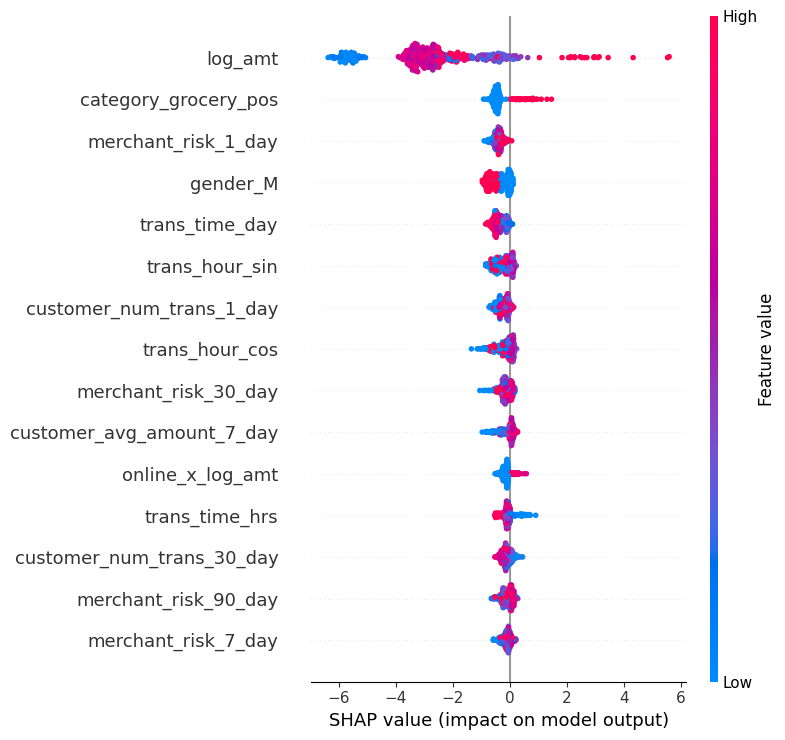

In [33]:
# ============================================================
# SHAP Beeswarm Plot
# ============================================================

shap.summary_plot(
    sv,
    features=shap_sample,
    feature_names=ALL_FEATURE_NAMES,
    plot_type="dot",
    max_display=15,
    show=True,
)

### Interpretation

The SHAP beeswarm shows both feature importance and direction. Points to the right push predictions toward fraud, while points to the left push predictions toward legitimate.

---

## Summary

### ML Pipeline Completed

This notebook builds a complete fraud detection machine learning pipeline from processed train/test files through model evaluation, threshold tuning, and SHAP explainability.

| Stage | Action | Improvement |
|---|---|---|
| Setup | Fixed `RANDOM_STATE=42` for reproducibility | Consistent random seed across workflow |
| Load | Loaded `X_train`, `X_test`, `y_train`, and `y_test` split files | Clear separation between features and target |
| Temporal check | Verified train/test date ranges | Helps identify possible temporal leakage |
| Feature engineering | Applied `engineer_features()` to `X_train` and `X_test` | Adds transaction amount, timing, velocity, and online-category signals |
| Leakage audit | Checked target exclusion, train-only scaling, train-only SMOTE, and temporal logic | Reduces risk of inflated model performance |
| Feature sets | Confirmed `is_fraud` is excluded from model features | Prevents direct target leakage |
| Feature importance | Used LightGBM feature importance | Identifies influential model inputs |
| Training | Trained Logistic Regression, Random Forest, LightGBM, and XGBoost | Compares baseline and nonlinear tree-based models |
| Evaluation | Compared F1, ROC-AUC, Average Precision, ROC curves, PR curves, and confusion matrices | Uses metrics appropriate for imbalanced fraud detection |
| Cross-validation | Used `TimeSeriesSplit` | Respects transaction time order during validation |
| Threshold tuning | Optimized decision threshold using F1 score | Balances precision and recall |
| Explainability | Used SHAP TreeExplainer | Explains which features influence fraud predictions |

### Key Leakage Protections

- `is_fraud` is used only as the target variable and does not enter the feature matrix.
- The scaler is fitted only on the training data, then applied to the test data.
- SMOTE is applied only after the train/test split and only to the training set.
- `engineer_features()` does not use the target variable or cross-set statistics.
- Temporal overlap between train and test data is checked.
- `TimeSeriesSplit` respects transaction order during cross-validation.
- Aggregate and velocity features are checked to reduce leakage risk.

### Final Data Science Interpretation

The pipeline shows that fraud detection requires more than high accuracy. Because fraud is rare, the model must be evaluated using metrics that focus on the minority class, especially F1 score, recall, precision, ROC-AUC, and Average Precision.

Tree-based models are expected to perform well because fraud patterns are often nonlinear and depend on interactions among transaction amount, timing, customer behavior, merchant behavior, and category-level signals.

The final model should be treated as a decision-support tool. In a real fraud operations setting, the classification threshold should be selected based on the cost of missed fraud compared with the cost of false fraud alerts.